<a href="https://colab.research.google.com/github/Suraiyaaurthi07/shape-cnn-classifier/blob/main/220152.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Configuration

In [1]:

GITHUB_REPO_URL = "https://github.com/Suraiyaaurthi07/shape-cnn-classifier.git"
STUDENT_ID = "220152"

IMG_SIZE = 128
BATCH_SIZE = 64
EPOCHS = 10
LR = 1e-3
CLASSES = ["Circle", "Square", "Triangle"]

N_TRAIN_PER_CLASS = 500
N_TEST_PER_CLASS = 100
SEED = 42


##Clone your repo (custom photos + place to save the model)

In [2]:
import os, subprocess

def run(cmd):
    print(f"$ {cmd}")
    subprocess.run(cmd, shell=True, check=True)

if not os.path.exists("my_repo"):
    run(f"git clone {GITHUB_REPO_URL} my_repo")

print("Done cloning.")


$ git clone https://github.com/Suraiyaaurthi07/shape-cnn-classifier.git my_repo
Done cloning.


##Imports

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image, ImageDraw, ImageFilter
import numpy as np
import matplotlib.pyplot as plt
import shutil, glob, random, math
from sklearn.metrics import confusion_matrix
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(SEED)
random.seed(SEED)


Using device: cuda


## Synthetic "standard dataset": hand-drawn-style shapes

/tmp/ipykernel_599/238776685.py:50: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(arr, mode="L")


Circle: 500 training images generated
Square: 500 training images generated
Triangle: 500 training images generated


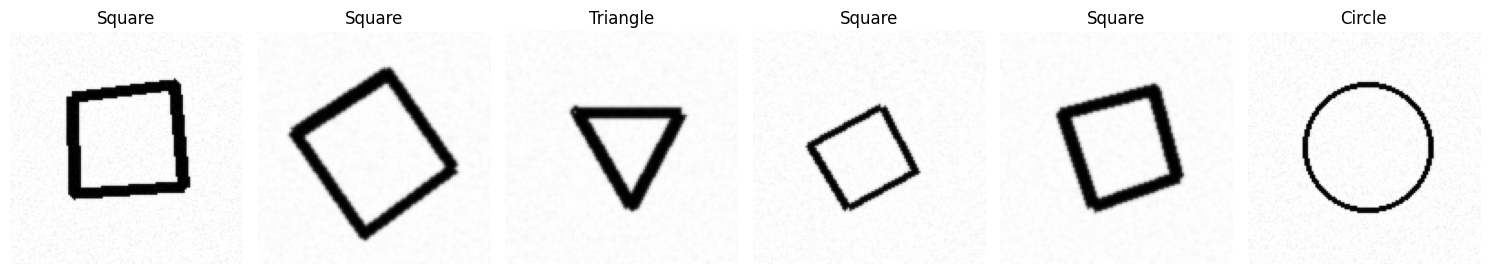

In [4]:
def _jitter(pt, amount, rng):
    return (pt[0] + rng.uniform(-amount, amount), pt[1] + rng.uniform(-amount, amount))

def draw_triangle(draw, cx, cy, r, angle_deg, width, rng, jitter_frac=0.06):
    pts = []
    for k in range(3):
        theta = math.radians(angle_deg + k * 120)
        pts.append((cx + r * math.cos(theta), cy + r * math.sin(theta)))
    pts = [_jitter(p, jitter_frac * r, rng) for p in pts]
    pts.append(pts[0])
    draw.line(pts, fill=0, width=width, joint="curve")

def draw_square(draw, cx, cy, r, angle_deg, width, rng, jitter_frac=0.06):
    pts = []
    for k in range(4):
        theta = math.radians(angle_deg + k * 90 + 45)
        pts.append((cx + r * math.cos(theta), cy + r * math.sin(theta)))
    pts = [_jitter(p, jitter_frac * r, rng) for p in pts]
    pts.append(pts[0])
    draw.line(pts, fill=0, width=width, joint="curve")

def draw_circle(draw, cx, cy, r, width, rng, wobble_frac=0.06):
    rx = r * (1 + rng.uniform(-wobble_frac, wobble_frac))
    ry = r * (1 + rng.uniform(-wobble_frac, wobble_frac))
    bbox = [cx - rx, cy - ry, cx + rx, cy + ry]
    draw.ellipse(bbox, outline=0, width=width)

def generate_shape_image(shape, img_size, rng):
    img = Image.new("L", (img_size, img_size), color=255)
    draw = ImageDraw.Draw(img)

    margin = img_size * 0.15
    max_r = img_size / 2 - margin
    r = rng.uniform(max_r * 0.55, max_r)
    cx = img_size / 2 + rng.uniform(-img_size * 0.05, img_size * 0.05)
    cy = img_size / 2 + rng.uniform(-img_size * 0.05, img_size * 0.05)
    width = rng.randint(3, 7)
    angle = rng.uniform(0, 360)

    if shape == "Triangle":
        draw_triangle(draw, cx, cy, r, angle, width, rng)
    elif shape == "Square":
        draw_square(draw, cx, cy, r, angle, width, rng)
    elif shape == "Circle":
        draw_circle(draw, cx, cy, r, width, rng)

    arr = np.array(img).astype(np.float32)
    noise = np.random.normal(0, 6, arr.shape)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    img = Image.fromarray(arr, mode="L")
    img = img.filter(ImageFilter.GaussianBlur(radius=rng.uniform(0.3, 0.8)))
    return img

def build_shape_dataset(root, n_per_class, seed):
    rng = random.Random(seed)
    if os.path.exists(root):
        shutil.rmtree(root)
    for cls in CLASSES:
        os.makedirs(os.path.join(root, cls), exist_ok=True)
        for i in range(n_per_class):
            img = generate_shape_image(cls, IMG_SIZE, rng)
            img.save(os.path.join(root, cls, f"{cls}_{i}.png"))

build_shape_dataset("shapes_dataset/train_raw", N_TRAIN_PER_CLASS, seed=SEED)
build_shape_dataset("shapes_dataset/test", N_TEST_PER_CLASS, seed=SEED + 1)

for cls in CLASSES:
    n = len(os.listdir(f"shapes_dataset/train_raw/{cls}"))
    print(f"{cls}: {n} training images generated")


fig, axes = plt.subplots(1, 6, figsize=(15, 3))
rng_preview = random.Random(0)
for ax in axes:
    cls = rng_preview.choice(CLASSES)
    img = generate_shape_image(cls, IMG_SIZE, rng_preview)
    ax.imshow(img, cmap="gray")
    ax.set_title(cls)
    ax.axis("off")
plt.tight_layout()
plt.show()


##Transforms & DataLoaders

In [5]:
MEAN, STD = [0.5], [0.5]

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

full_train_raw = ImageFolder("shapes_dataset/train_raw", transform=train_transform)
test_dataset = ImageFolder("shapes_dataset/test", transform=eval_transform)

n_total = len(full_train_raw)
n_val = int(0.15 * n_total)
n_train = n_total - n_val
train_dataset, val_dataset = random_split(full_train_raw, [n_train, n_val],
                                           generator=torch.Generator().manual_seed(SEED))
val_dataset.dataset = ImageFolder("shapes_dataset/train_raw", transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = full_train_raw.classes
print("Classes:", class_names)
print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}")


Classes: ['Circle', 'Square', 'Triangle']
Train: 1275  Val: 225  Test: 300


##CNN Model

In [6]:
class CNN(nn.Module):
    def __init__(self, num_classes=3):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),        # 128 -> 64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),        # 64 -> 32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),        # 32 -> 16
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNN(num_classes=len(class_names)).to(device)
print(model)


CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=3, bias=True)
  )
)


##Training Loop


In [7]:
LOAD_SAVED_MODEL = False
SAVED_MODEL_PATH = f"my_repo/model/{STUDENT_ID}.pth"

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

if LOAD_SAVED_MODEL and os.path.exists(SAVED_MODEL_PATH):
    model.load_state_dict(torch.load(SAVED_MODEL_PATH, map_location=device))
    model.to(device)
    print(f"Loaded saved weights from {SAVED_MODEL_PATH}")
else:
    for epoch in range(EPOCHS):
        tr_loss, tr_acc = run_epoch(train_loader, train=True)
        val_loss, val_acc = run_epoch(val_loader, train=False)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"train_loss={tr_loss:.4f} train_acc={tr_acc:.3f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}")

    os.makedirs("model", exist_ok=True)
    torch.save(model.state_dict(), f"model/{STUDENT_ID}.pth")
    print(f"Saved model weights to model/{STUDENT_ID}.pth")
    print("--> Copy this file into your repo's model/ folder and push to GitHub.")


Epoch 1/10 | train_loss=1.0326 train_acc=0.515 | val_loss=0.7521 val_acc=0.609
Epoch 2/10 | train_loss=0.6158 train_acc=0.696 | val_loss=0.3334 val_acc=0.893
Epoch 3/10 | train_loss=0.2158 train_acc=0.925 | val_loss=0.0529 val_acc=0.987
Epoch 4/10 | train_loss=0.0358 train_acc=0.990 | val_loss=0.0045 val_acc=1.000
Epoch 5/10 | train_loss=0.0203 train_acc=0.995 | val_loss=0.0028 val_acc=1.000
Epoch 6/10 | train_loss=0.0294 train_acc=0.992 | val_loss=0.0034 val_acc=1.000
Epoch 7/10 | train_loss=0.0138 train_acc=0.996 | val_loss=0.0011 val_acc=1.000
Epoch 8/10 | train_loss=0.0052 train_acc=0.998 | val_loss=0.0005 val_acc=1.000
Epoch 9/10 | train_loss=0.0036 train_acc=1.000 | val_loss=0.0003 val_acc=1.000
Epoch 10/10 | train_loss=0.0015 train_acc=1.000 | val_loss=0.0001 val_acc=1.000
Saved model weights to model/220152.pth
--> Copy this file into your repo's model/ folder and push to GitHub.


##Training History Plots (Loss & Accuracy vs Epochs)

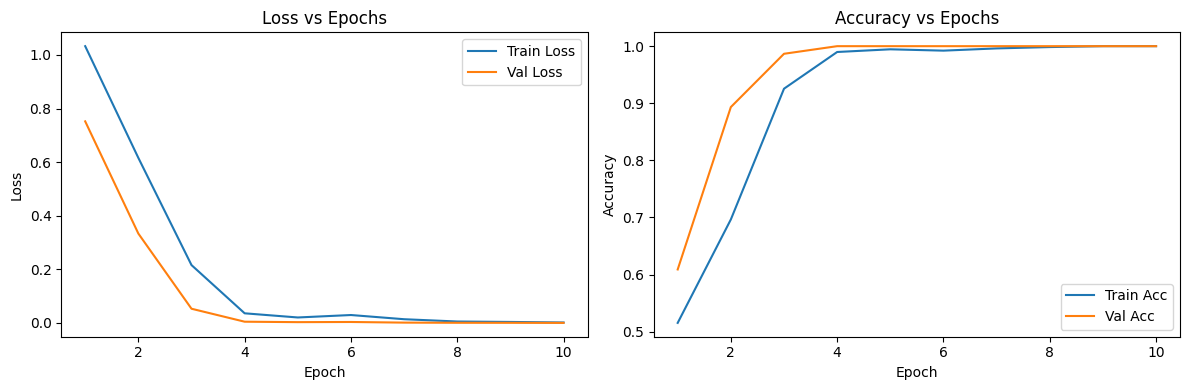

In [8]:
if history["train_loss"]:
    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs_range, history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss vs Epochs")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

    axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs_range, history["val_acc"], label="Val Acc")
    axes[1].set_title("Accuracy vs Epochs")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150)
    plt.show()
else:
    print("Skipped plotting -- model was loaded from saved weights, no training history available.")


##Confusion Matrix (on synthetic Test set)

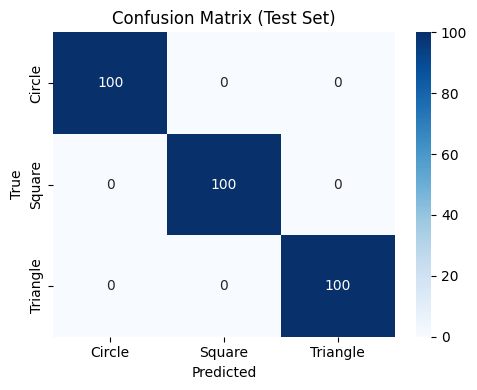

Test accuracy: 1.000


In [9]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

test_acc = (np.array(all_preds) == np.array(all_labels)).mean()
print(f"Test accuracy: {test_acc:.3f}")


##Visual Error Analysis — 3 misclassified test images

In [10]:
wrong_idx = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p != l]
print(f"{len(wrong_idx)} misclassified out of {len(all_labels)}")

sample_wrong = random.sample(wrong_idx, min(3, len(wrong_idx))) if wrong_idx else []

if sample_wrong:
    fig, axes = plt.subplots(1, len(sample_wrong), figsize=(4 * len(sample_wrong), 4))
    if len(sample_wrong) == 1:
        axes = [axes]
    for ax, idx in zip(axes, sample_wrong):
        img_tensor, true_label = test_dataset[idx]
        img = img_tensor.squeeze(0).numpy()
        img = img * STD[0] + MEAN[0]   # unnormalize
        img = np.clip(img, 0, 1)
        ax.imshow(img, cmap="gray")
        ax.set_title(f"True: {class_names[true_label]}\nPred: {class_names[all_preds[idx]]}")
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("error_analysis.png", dpi=150)
    plt.show()
else:
    print("No misclassified images -- model got 100% on the test set!")


0 misclassified out of 300
No misclassified images -- model got 100% on the test set!


##Real-World Prediction — Your Hand-Drawn Photos


In [11]:
phone_dir = "my_repo/dataset"
image_paths = sorted(glob.glob(os.path.join(phone_dir, "*")))
image_paths = [p for p in image_paths if p.lower().endswith((".jpg", ".jpeg", ".png"))]
print(f"Found {len(image_paths)} hand-drawn photos:", image_paths)

model.eval()
results = []
with torch.no_grad():
    for path in image_paths:
        img = Image.open(path).convert("RGB")
        tensor = eval_transform(img).unsqueeze(0).to(device)
        output = model(tensor)
        probs = torch.softmax(output, dim=1).cpu().numpy()[0]
        pred_idx = probs.argmax()
        results.append((path, class_names[pred_idx], probs[pred_idx] * 100, probs))


Found 10 hand-drawn photos: ['my_repo/dataset/circle1.jpeg', 'my_repo/dataset/circle2.jpeg', 'my_repo/dataset/circle3.jpeg', 'my_repo/dataset/square1.jpeg', 'my_repo/dataset/square2.jpeg', 'my_repo/dataset/square3.jpeg', 'my_repo/dataset/triangle1.jpeg', 'my_repo/dataset/triangle2.jpeg', 'my_repo/dataset/triangle3.jpeg', 'my_repo/dataset/triangle4.jpeg']


##Custom Prediction Gallery

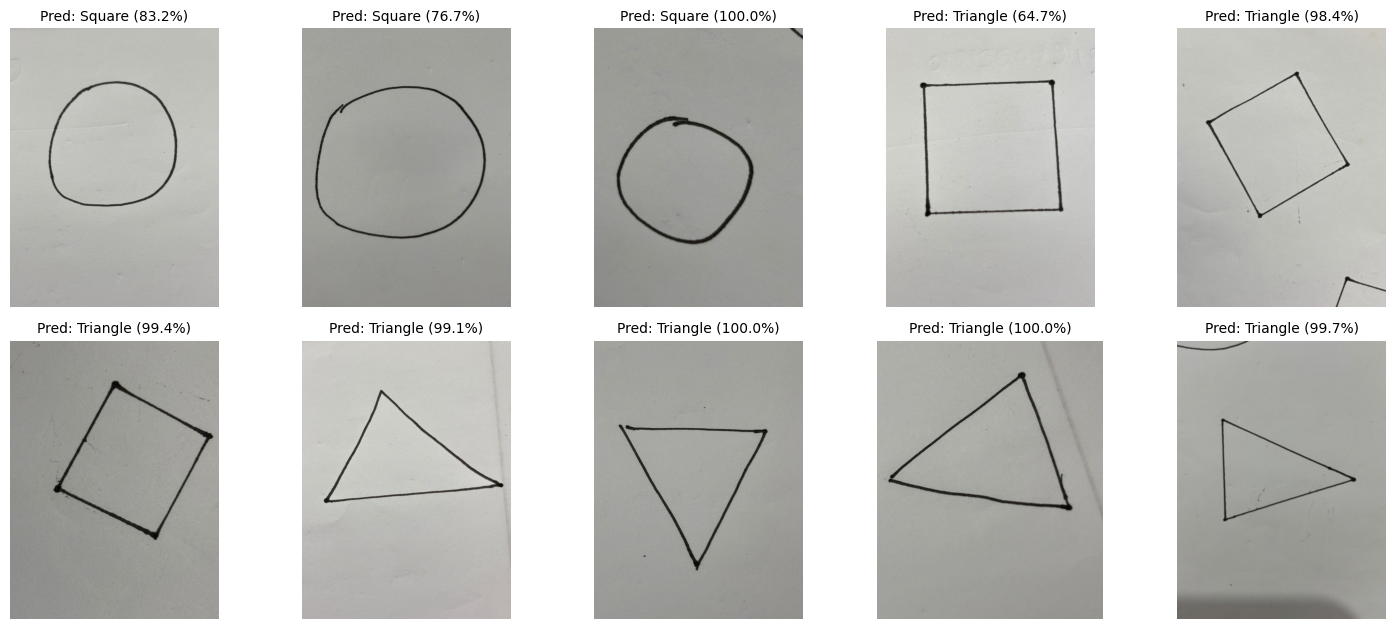

circle1.jpeg -> Pred: Square (83.2%)  [Circle: 15.9%, Square: 83.2%, Triangle: 1.0%]
circle2.jpeg -> Pred: Square (76.7%)  [Circle: 23.1%, Square: 76.7%, Triangle: 0.3%]
circle3.jpeg -> Pred: Square (100.0%)  [Circle: 0.0%, Square: 100.0%, Triangle: 0.0%]
square1.jpeg -> Pred: Triangle (64.7%)  [Circle: 0.6%, Square: 34.7%, Triangle: 64.7%]
square2.jpeg -> Pred: Triangle (98.4%)  [Circle: 0.0%, Square: 1.6%, Triangle: 98.4%]
square3.jpeg -> Pred: Triangle (99.4%)  [Circle: 0.0%, Square: 0.6%, Triangle: 99.4%]
triangle1.jpeg -> Pred: Triangle (99.1%)  [Circle: 0.0%, Square: 0.9%, Triangle: 99.1%]
triangle2.jpeg -> Pred: Triangle (100.0%)  [Circle: 0.0%, Square: 0.0%, Triangle: 100.0%]
triangle3.jpeg -> Pred: Triangle (100.0%)  [Circle: 0.0%, Square: 0.0%, Triangle: 100.0%]
triangle4.jpeg -> Pred: Triangle (99.7%)  [Circle: 0.0%, Square: 0.3%, Triangle: 99.7%]


In [12]:
n = len(results)
cols = 5
rows = (n + cols - 1) // cols if n > 0 else 1
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.2))
axes = np.array(axes).reshape(-1)

for ax, (path, pred_class, conf, probs) in zip(axes, results):
    img = Image.open(path).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"Pred: {pred_class} ({conf:.1f}%)", fontsize=10)
    ax.axis("off")

for ax in axes[len(results):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("phone_predictions.png", dpi=150)
plt.show()

for path, pred_class, conf, probs in results:
    prob_str = ", ".join(f"{c}: {p*100:.1f}%" for c, p in zip(class_names, probs))
    print(f"{os.path.basename(path)} -> Pred: {pred_class} ({conf:.1f}%)  [{prob_str}]")
